In [12]:
import duckdb, pandas as pd 
from pathlib import Path
print("OK")

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

OK


In [13]:
DB_PATH = ROOT / "data" / "olist.db"
if "con" in globals():
    try:
        con.close()
    except Exception:
        pass
con = duckdb.connect(str(DB_PATH))
print("Connected:", DB_PATH)

Connected: /Users/user/Desktop/data-science-projects/Marketplace-Incentives-Causal-Inference/data/olist.db


In [14]:
con.sql("SHOW TABLES").df()

,name
0,customers
1,order_items
2,order_payments
3,order_reviews
4,orders
5,orders_analytical


In [15]:
con.sql("SELECT * FROM orders_analytical LIMIT 3").df()

,order_id,customer_id,customer_state,purchase_ts,purchase_date,purchase_month,order_status,delivered_customer_ts,estimated_delivery_date,n_items,n_sellers,gross_revenue,freight_total,payment_total,n_payments,review_score,is_delivered,delivery_days,on_time
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP,2017-10-02 10:56:33,2017-10-02,2017-10-01,delivered,2017-10-10 21:25:13,2017-10-18,1,1,29.99,8.72,38.71,3,4.0,True,8,1
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA,2018-07-24 20:41:37,2018-07-24,2018-07-01,delivered,2018-08-07 15:27:45,2018-08-13,1,1,118.70,22.76,141.46,1,4.0,True,14,1
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO,2018-08-08 08:38:49,2018-08-08,2018-08-01,delivered,2018-08-17 18:06:29,2018-09-04,1,1,159.90,19.22,179.12,1,5.0,True,9,1


In [16]:
con.execute(""" 
CREATE OR REPLACE VIEW orders_treated AS 
    SELECT *, 
    CASE WHEN customer_state IN ('SP', 'RJ', 'MG') THEN 1 ELSE 0 END AS treated_region, 
    CASE WHEN purchase_date >= '2017-06-01' THEN 1 ELSE 0 END AS post, 
    CASE WHEN treated_region = 1 AND post = 1 THEN 1 ELSE 0 END AS incentive_flag
    FROM orders_analytical;
""" )

In [24]:

con.sql("""
SELECT treated_region, post, COUNT(*) AS n_orders
FROM orders_treated
GROUP BY treated_region, post
ORDER BY 1, 2;
""").df()


,treated_region,post,n_orders
0,0,0,4188
1,0,1,29020
2,1,0,7507
3,1,1,58726


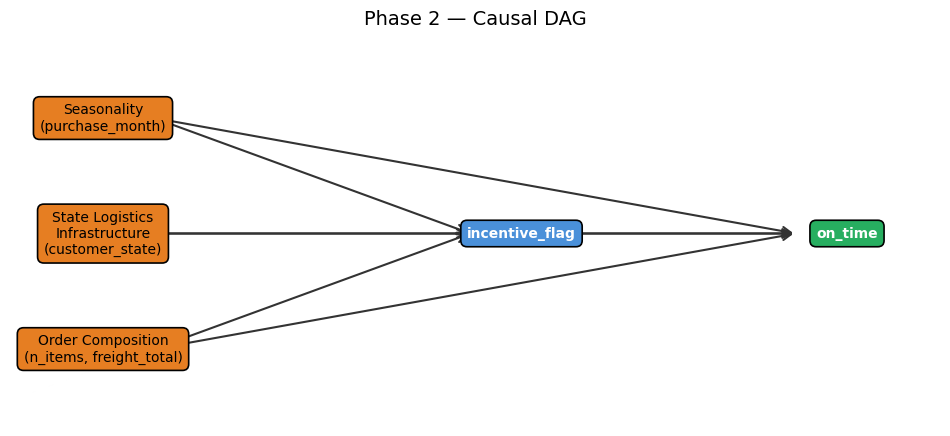

Confounders (each affects BOTH incentive_flag and on_time):
- Seasonality: cutoff timing overlaps peak demand months
- State logistics infrastructure: SP/RJ/MG selected because they are hub states
- Order composition: hub states have different basket size / freight patterns

Biggest parallel-trends threat: state logistics infrastructure


In [29]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 5)
ax.axis("off")

nodes = {
    "seasonality": (1.0, 4.0, "Seasonality\n(purchase_month)"),
    "state_infra": (1.0, 2.5, "State Logistics\nInfrastructure\n(customer_state)"),
    "order_comp": (1.0, 1.0, "Order Composition\n(n_items, freight_total)"),
    "incentive_flag": (5.5, 2.5, "incentive_flag"),
    "on_time": (9.0, 2.5, "on_time"),
}

for key, (x, y, label) in nodes.items():
    color = "#4a90d9" if key == "incentive_flag" else "#27ae60" if key == "on_time" else "#e67e22"
    ax.text(
        x, y, label, ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.45", fc=color, ec="black", lw=1.2),
        fontsize=10, color="white" if color != "#e67e22" else "black", weight="bold" if key in {"incentive_flag", "on_time"} else "normal",
    )

arrows = [
    ("seasonality", "incentive_flag"), ("seasonality", "on_time"),
    ("state_infra", "incentive_flag"), ("state_infra", "on_time"),
    ("order_comp", "incentive_flag"), ("order_comp", "on_time"),
    ("incentive_flag", "on_time"),
]

for start, end in arrows:
    x1, y1, _ = nodes[start]
    x2, y2, _ = nodes[end]
    ax.add_patch(FancyArrowPatch((x1 + 0.55, y1), (x2 - 0.55, y2), arrowstyle="->", mutation_scale=15, lw=1.5, color="#333"))

ax.set_title("Phase 2 — Causal DAG", fontsize=14, pad=12)
plt.show()

print("Confounders (each affects BOTH incentive_flag and on_time):")
print("- Seasonality: cutoff timing overlaps peak demand months")
print("- State logistics infrastructure: SP/RJ/MG selected because they are hub states")
print("- Order composition: hub states have different basket size / freight patterns")
print("\nBiggest parallel-trends threat: state logistics infrastructure")

Creating a Pre-period balance table 

In [ ]:
df = con.sql("""
SELECT 
CASE WHEN treated_region = 1 THEN 'treated' ELSE 'control' END AS arm,
COUNT(*) AS n_orders, 
AVG(on_time) AS on_time_rate,
AVG(delivery_days) AS avg_delivery_days, 
AVG(n_items) AS avg_n_items, 
AVG(gross_revenue) AS avg_gross_revenue, 
AVG(freight_total) AS avg_freight_total
FROM orders_treated 
WHERE purchase_date < '2017-06-01'
AND is_delivered = TRUE
GROUP BY 1; 
"""
  ).df() 
df



,arm,n_orders,on_time_rate,avg_delivery_days,avg_n_items,avg_gross_revenue,avg_freight_total
0,treated,7102,0.964095,11.025908,1.136300,135.360517,19.084161
1,control,3963,0.951540,16.866482,1.132475,155.026276,26.781466



## Phase 3 - Pre-Period Balance Table Interpretation

**Sample:** delivered orders only, `purchase_date < '2017-06-01'`  
**Grouping:** `treated_region` (SP/RJ/MG vs all other states) — not `incentive_flag`, which is always 0 pre-cutoff.

These are pre-period estimates of \(E[O \mid \text{group}, \text{pre}]\) and confounder-proxy levels. In DiD notation they reflect **δ_treated** vs **δ_control** — time-invariant baseline differences DiD is designed to difference out.

Our DAG has **three backdoor paths** (not one): T ← S → O (seasonality), T ← W → O (state infrastructure), T ← C → O (order composition). This table checks level gaps (δ) on observables linked to W and C; it cannot check S or λ.

### What stands out

1. **Outcome level (δ on O):** Treated states are slightly *more* on-time pre-cutoff (96.4% vs 95.2%). This is a level gap, not evidence against DiD — DiD removes constant δ differences via the double difference.

2. **Infrastructure proxy (δ on W):** The largest gap is `avg_delivery_days` (11.0 vs 16.9). Treated hub states deliver ~6 days faster pre-cutoff — the clearest empirical signal of the **T ← W → O** backdoor path in this table.

3. **Order composition (δ on C):** `avg_n_items` is nearly identical (~1.13–1.14). Revenue and freight are higher in control states, suggesting modest geographic/composition differences but not a dramatic basket-size imbalance on levels.

4. **RJ heterogeneity within treated arm:** EDA showed RJ at ~87.9% on-time vs SP/MG at ~95%+. The treated-arm average (96.4%) is pulled up by SP/MG volume. DiD estimates a **weighted average treatment effect** across all three states — not a clean RJ-specific effect. This is a limitation to flag, not a parallel-trends violation.

### What this table does NOT establish

This is a **cross-sectional level check (δ)**, not a **trajectory check (λ)**. Passing balance on observables does not confirm parallel trends (\(\lambda_{\text{treated}} = \lambda_{\text{control}}\)). Seasonality (S) is especially untestable here — the cutoff changes the calendar mix of pre vs post. That requires the pre-period monthly on-time plot (Week 3).

### Honest framing

This is a simulated quasi-experiment on observational data, not a real A/B test. The balance table supports that treated and control are broadly comparable on composition (C) but differ meaningfully on logistics proxies (W) — consistent with two of the three backdoor paths in our DAG.

## Week 2 Summary

### Treatment definition (locked)

- **Treated region:** `customer_state IN ('SP', 'RJ', 'MG')`
- **Cutoff:** `2017-06-01` (simulated policy start)
- **Post:** `purchase_date >= '2017-06-01'`
- **Treatment:** `incentive_flag = treated_region AND post`
- **Mart:** `orders_treated` view on `orders_analytical` (one row per `order_id`, 99,441 total)

### 2×2 design (verified)

| | Pre | Post |
|---|---|---|
| **Control** | 4,188 | 29,020 |
| **Treated** | 7,507 | 58,726 |

### Causal structure

- **Outcome (O):** `on_time` (delivered orders only)
- **Treatment (T):** `incentive_flag`
- **Three backdoor paths (forks):**
  - T ← **S** → O (seasonality / `purchase_month`)
  - T ← **W** → O (state logistics infrastructure / `customer_state`)
  - T ← **C** → O (order composition / `n_items`, `freight_total`)

DiD strategy: difference out time-invariant δ (level differences between groups). **W** is the clearest δ signal in the balance table; **S** and **C** are bigger threats to parallel trends (λ) because they can trend differently across arms over time. Parallel trends assumes no time-varying backdoor path opens at the cutoff (λ_treated = λ_control) — **not yet tested**.

### Phase 3 balance table (δ check)

Pre-period delivered sample: treated 7,102 orders vs control 3,963.

- Treated slightly higher on-time pre-cutoff (96.4% vs 95.2%) — level gap, not a DiD failure
- Largest gap on `avg_delivery_days` (11.0 vs 16.9) — strongest δ evidence for **W**
- `avg_n_items` ~balanced; revenue/freight modestly differ — partial δ check on **C**
- RJ heterogeneity within treated arm (~87.9% vs SP/MG ~95%+) — τ̂ is a weighted average, not state-specific

### Honest framing

This is a **simulated quasi-experiment on observational data**, not a real A/B test. Always describe it as a simulated regional rollout / DiD.

### Week 3 next steps

1. **Parallel trends plot** — pre-period monthly `on_time_rate` by arm (λ check; especially relevant for **S** and **C**)
2. **DiD point estimate** — (T_post − T_pre) − (C_post − C_pre) for τ̂
3. **Bootstrap CI** — resample at order level, 1000+ iterations

Reference: `docs/DiD_CONCEPTUAL_REFERENCE.md` (single-W sections are pedagogical simplification; full DAG has S, W, C)